In [1]:
import pandas as pd
df = pd.read_csv("../data/raw_churn_data.csv")
df.shape

(10000, 12)

In [2]:
df.columns.tolist()

['customer_id',
 'credit_score',
 'country',
 'gender',
 'age',
 'tenure',
 'balance',
 'products_number',
 'credit_card',
 'active_member',
 'estimated_salary',
 'churn']

In [3]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df['customer_id'].duplicated().sum()

np.int64(0)

In [7]:
df['churn'].value_counts()

churn
0    7963
1    2037
Name: count, dtype: int64

In [8]:
df['churn'].value_counts(normalize=True)

churn
0    0.7963
1    0.2037
Name: proportion, dtype: float64

In [9]:
df.groupby('country')['churn'].mean()

country
France     0.161548
Germany    0.324432
Spain      0.166734
Name: churn, dtype: float64

In [10]:
df.groupby('gender')['churn'].mean()

gender
Female    0.250715
Male      0.164559
Name: churn, dtype: float64

In [11]:
df.groupby('churn')[['credit_score', 'age', 'balance', 'estimated_salary']].mean()

,credit_score,age,balance,estimated_salary
churn,,,,
0,651.853196,37.408389,72745.296779,99738.391772
1,645.351497,44.837997,91108.539337,101465.677531


In [12]:
df.groupby('churn')[['tenure', 'products_number', 'credit_card', 'active_member']].mean()

,tenure,products_number,credit_card,active_member
churn,,,,
0,5.033279,1.544267,0.707146,0.554565
1,4.932744,1.475209,0.699067,0.360825


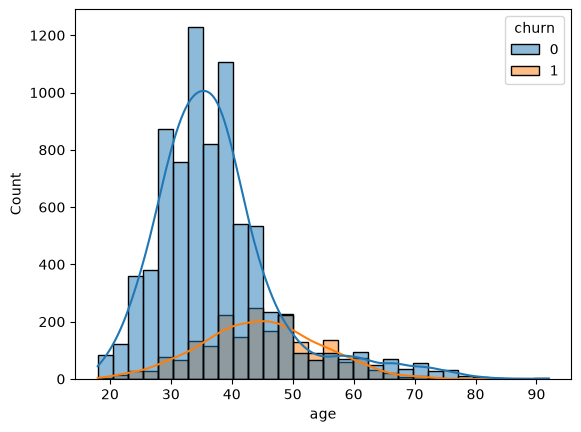

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df, x='age', hue='churn', kde=True, bins=30)
plt.show()

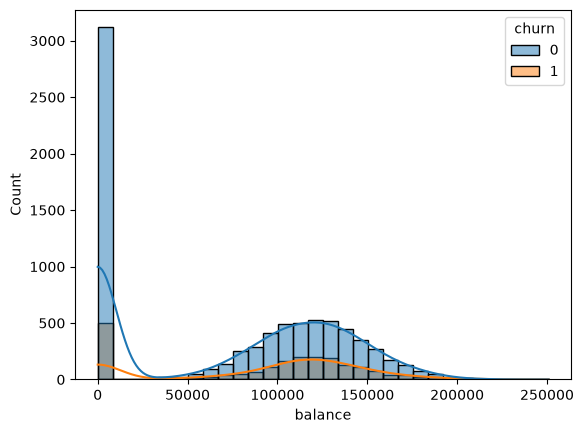

In [14]:
sns.histplot(data=df, x='balance', hue='churn', kde=True, bins=30)
plt.show()

In [15]:
df['has_zero_balance'] = df['balance'] == 0
df.groupby('has_zero_balance')['churn'].mean()

has_zero_balance
False    0.240796
True     0.138236
Name: churn, dtype: float64

In [16]:
df.corr(numeric_only=True)['churn'].sort_values(ascending=False)

churn               1.000000
age                 0.285323
balance             0.118533
estimated_salary    0.012097
customer_id        -0.006248
credit_card        -0.007138
tenure             -0.014001
credit_score       -0.027094
products_number    -0.047820
has_zero_balance   -0.122357
active_member      -0.156128
Name: churn, dtype: float64

In [17]:
df.groupby('products_number')['churn'].mean()

products_number
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: churn, dtype: float64

In [18]:
df['products_number'].value_counts()

products_number
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

In [19]:
df.groupby('tenure')['churn'].mean()

tenure
0     0.230024
1     0.224155
2     0.191794
3     0.211100
4     0.205258
5     0.206522
6     0.202689
7     0.172179
8     0.192195
9     0.216463
10    0.206122
Name: churn, dtype: float64

In [20]:
df['credit_score_bucket'] = pd.cut(df['credit_score'], bins=5)
df.groupby('credit_score_bucket')['churn'].mean()

credit_score_bucket
(349.5, 450.0]    0.322751
(450.0, 550.0]    0.214385
(550.0, 650.0]    0.207780
(650.0, 750.0]    0.192496
(750.0, 850.0]    0.195870
Name: churn, dtype: float64

## EDA Summary

**Dataset:** 10,000 customers, 12 columns, no missing values, no duplicates.

**Target variable:** `churn` - 20.4% churned, 79.6% stayed (moderate class imbalance; accuracy alone won't be a meaningful metric for this problem).

### Strong predictors

- **`age`** - churners average ~45 years old vs ~37 for non-churners. Histogram confirms a smooth, genuine upward shift in churn risk with age (not a spike or artifact).
- **`products_number`** - highly non-linear relationship, missed almost entirely by the raw correlation coefficient (-0.048, near zero). Actual churn rates by product count: 1 product = 27.7%, 2 products = 7.6% (safest group), 3 products = 82.7%, 4 products = 100% (though only 60 customers hold 4 products, so treat that exact figure cautiously, the direction is still a strong, real signal).
- **`country`** - Germany churns at ~32.4%, roughly double France (16.2%) and Spain (16.7%).
- **`active_member`** - active members churn less often (36.1% of churners were inactive vs only 44.5% active... simplify:) active members churn at a lower rate than inactive members (active-member rate: 55% among stayers vs 36% among churners).
- **`balance`** - not a simple linear effect. Distribution is bimodal: a large cluster of customers with exactly zero balance (low churn, 13.8%) and a separate cluster of funded customers (balance 50k+, higher churn, 24.1% among the non-zero group). Raw balance correlation understated this because it blends two different populations.
- **`gender`** - Female customers churn at ~25.1% vs ~16.5% for Male customers.

### Weak predictors

- **`tenure`** - flat across all values (17–23% churn range, no trend). Confirmed via groupby, not just correlation.
- **`credit_card`** - no meaningful difference (0.71 vs 0.70 average ownership between groups).
- **`estimated_salary`** - no relationship (correlation ~0.01).
- **`credit_score`** - mostly flat (~19–21% churn) except the lowest bucket (below ~450), which churns at 32.3% - a smaller, less certain sample, but a plausible risk-flag pattern.

### Implications for Phase 3

- `products_number`, `balance`, and `credit_score` all show effects that raw numeric values or linear correlation would miss or understate, feature engineering (e.g. a `has_zero_balance` flag, bucketing `products_number` and `credit_score`) is likely to matter more than using these as raw continuous/numeric inputs.
- `country` and `gender` will need categorical encoding before modeling.
- `tenure`, `credit_card`, and `estimated_salary` are candidates for exclusion or de-prioritization, pending confirmation once we move into actual modeling (Phase 4) - EDA suggests weak signal, but the final feature set should be validated with the model itself, not decided on EDA alone.

In [21]:
import sys
sys.path.append('..')

from src.preprocessing import drop_unused_columns

df_test = drop_unused_columns(df)
df_test.columns.tolist()

['credit_score',
 'country',
 'gender',
 'age',
 'tenure',
 'balance',
 'products_number',
 'credit_card',
 'active_member',
 'estimated_salary',
 'churn',
 'has_zero_balance',
 'credit_score_bucket']

In [22]:
from src.preprocessing import add_zero_balance_flag

df_test2 = add_zero_balance_flag(df)
df_test2[['balance', 'has_zero_balance']].head()

,balance,has_zero_balance
0,0.00,True
1,83807.86,False
2,159660.80,False
3,0.00,True
4,125510.82,False


In [23]:
from src.preprocessing import encode_categoricals

df_test3 = encode_categoricals(df)
df_test3.columns.tolist()

['customer_id',
 'credit_score',
 'age',
 'tenure',
 'balance',
 'products_number',
 'credit_card',
 'active_member',
 'estimated_salary',
 'churn',
 'has_zero_balance',
 'credit_score_bucket',
 'country_Germany',
 'country_Spain',
 'gender_Male']